In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('INvideos.csv')
df.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...


In [3]:
df.shape

(37352, 16)

In [4]:
df.columns.tolist()

['video_id',
 'trending_date',
 'title',
 'channel_title',
 'category_id',
 'publish_time',
 'tags',
 'views',
 'likes',
 'dislikes',
 'comment_count',
 'thumbnail_link',
 'comments_disabled',
 'ratings_disabled',
 'video_error_or_removed',
 'description']

In [5]:
df.drop(columns=['thumbnail_link','description'], inplace=True)

In [6]:
df.isnull().sum()

video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(4263)

In [8]:
df.drop_duplicates(subset=['video_id','channel_title', 'trending_date'], inplace=True)

In [9]:
df.shape

(32706, 14)

In [10]:
df.dtypes

video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_time              object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
dtype: object

In [11]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [12]:
df['publish_time'] = pd.to_datetime(df['publish_time'])

In [13]:
df['publish_date']  = df['publish_time'].dt.date
df['publish_hour']  = df['publish_time'].dt.hour
df['publish_day']   = df['publish_time'].dt.day_name()
df['publish_month'] = df['publish_time'].dt.month

In [14]:
df.head(3)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,publish_date,publish_hour,publish_day,publish_month
0,kzwfHumJyYc,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False,2017-11-12,12,Sunday,11
1,zUZ1z7FwLc8,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13 05:43:56+00:00,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False,2017-11-13,5,Monday,11
2,10L1hZ9qa58,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12 15:48:08+00:00,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False,2017-11-12,15,Sunday,11


In [15]:
df['engagement_rate'] = (df['likes']+df['comment_count']) / df['views']

### Category-wise performance comparison

In [24]:
np.round(df.groupby('category_id').agg(
    avg_views = ('views', 'mean'), 
    avg_likes = ('likes', 'mean'), 
    avg_comments = ('comment_count', 'mean'),  
    avg_engagement = ('engagement_rate', 'mean'), 
    total_videos = ('video_id', 'count')
).reset_index().sort_values('avg_views', ascending=False),2)

,category_id,avg_views,avg_likes,avg_comments,avg_engagement,total_videos
6,20,3606368.82,92729.62,8833.82,0.04,55
15,30,3191953.00,40975.00,2296.20,0.02,10
2,10,2443632.03,61392.44,4182.16,0.03,3187
0,1,2148783.90,37130.38,3077.40,0.02,1436
4,17,1781696.38,41650.00,3463.47,0.02,637
3,15,1626581.00,120844.67,14018.67,0.06,3
9,24,870964.34,21062.59,2288.01,0.02,14636
13,28,844699.53,34902.07,14519.95,0.10,514
11,26,842092.73,9041.72,864.90,0.02,798
8,23,799937.47,47473.32,3749.82,0.06,2897


### Correlation heatmap (views vs likes vs comments)

In [46]:
col = df[['views', 'likes', 'comment_count', 'dislikes']]
corr = col.corr()
corr

,views,likes,comment_count,dislikes
views,1.000000,0.854842,0.697010,0.556635
likes,0.854842,1.000000,0.791501,0.506871
comment_count,0.697010,0.791501,1.000000,0.744129
dislikes,0.556635,0.506871,0.744129,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

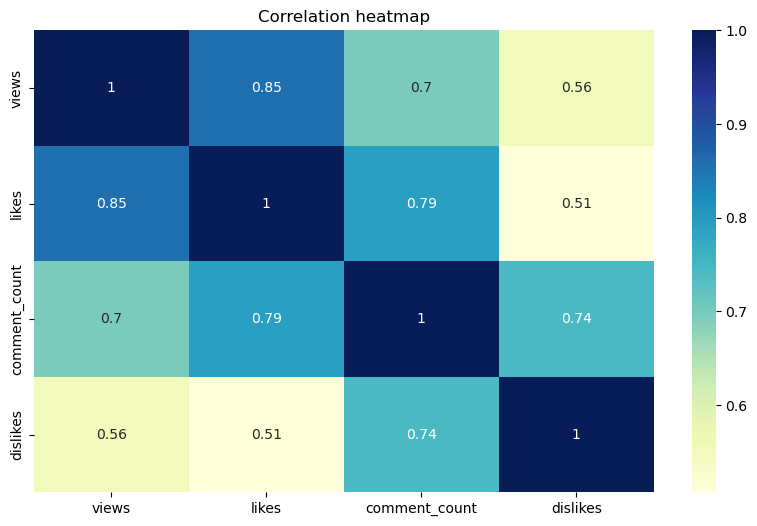

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu')
plt.title('Correlation heatmap')

### Time-series: trending patterns by day/month 

In [53]:
df.groupby('publish_day')['engagement_rate'].mean().reset_index().sort_values(by='engagement_rate', ascending=False)

,publish_day,engagement_rate
4,Thursday,0.025723
0,Friday,0.025491
2,Saturday,0.024214
3,Sunday,0.023986
5,Tuesday,0.023480
1,Monday,0.023398
6,Wednesday,0.022672


In [54]:
df.groupby('publish_month')['engagement_rate'].mean().reset_index().sort_values(by='engagement_rate', ascending=False)

,publish_month,engagement_rate
5,6,0.031795
4,5,0.026405
3,4,0.026199
7,12,0.023732
2,3,0.023266
0,1,0.023115
1,2,0.023060
6,11,0.021713


### Outlier detection — what makes a video explode?

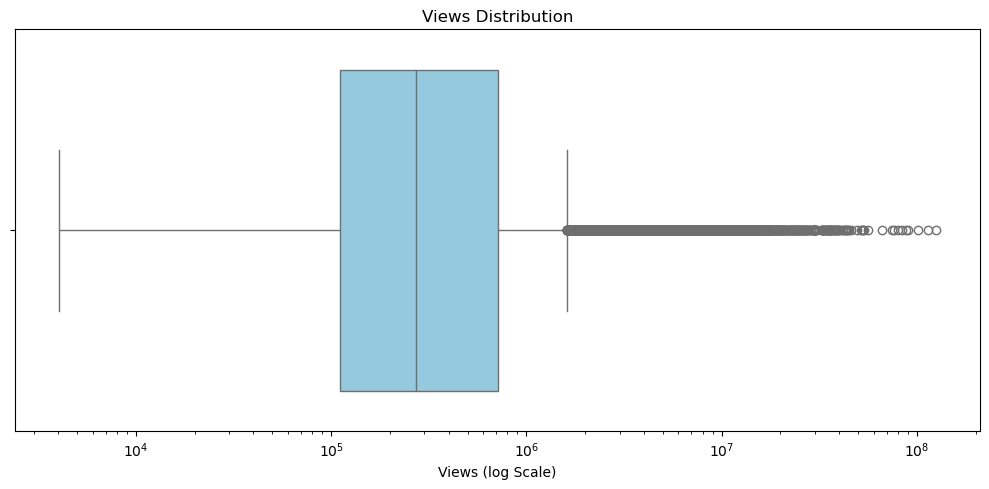

In [67]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['views'], color='skyblue')
plt.xscale('log')
plt.xlabel('Views (log Scale)')
plt.title('Views Distribution')
plt.tight_layout()
plt.show()